# PlantCare AI — Notebook 01b: three-architecture classification benchmark

**Scope of this notebook: image classification only.** Every green-channel / ExG lesion
step from the previous version has been removed — no `analyse_leaf`, no `assess_severity`,
no leaf mask, no lesion 4th channel, no annotated boxes, no severity bands. The manifest,
the loaders, the training loop and the metrics are all pure whole-image classification.

**What is compared**

| key | architecture | how it is used here |
|---|---|---|
| `efficientnet_b0` | EfficientNet-B0 (ImageNet) | standard classifier — `classifier[1]` replaced |
| `densenet121` | DenseNet-121 (ImageNet) | standard classifier — `classifier` replaced |
| `faster_rcnn_cls` | Faster R-CNN R50-FPN (COCO) | **detector adapted to whole-image classification**: ResNet-50 + FPN backbone → RoIAlign on a single full-frame box → the detector's own `box_head` (2-layer MLP) → new linear head. The RPN is never constructed, so **no region proposals are generated** |

All three see the same manifest, the same splits, the same transforms, the same
augmentation, the same optimiser/scheduler family and the same number of epochs, so the
only variable is the architecture.

**What is recorded, per epoch, per model:** training loss, validation loss, validation
accuracy (training accuracy and epoch wall-time come along for free). Curves are drawn
comparatively — one panel per metric, three lines per panel. Then each model's best
checkpoint is evaluated once on the held-out test split and the test accuracies are
tabled and plotted side by side.

## 1. Install + imports

In [14]:
!pip install -q -U openpyxl scikit-learn

from pathlib import Path
from collections import defaultdict
from contextlib import nullcontext
import json
import os
import random
import re
import shutil
import time
import warnings

warnings.filterwarnings("ignore")

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision
from torchvision import transforms

from sklearn.metrics import (accuracy_score, balanced_accuracy_score, f1_score,
                             classification_report, confusion_matrix)
from sklearn.model_selection import train_test_split

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE, "| torch", torch.__version__, "| torchvision", torchvision.__version__)

Device: cuda | torch 2.10.0+cu128 | torchvision 0.25.0+cu128


## 2. Settings

One knob that matters before you start: `EPOCHS`. Three models is three trainings, and
the Faster R-CNN backbone (ResNet-50 + FPN) is roughly 2–3× the cost per epoch of the
other two. At 15 epochs on ~29k training images expect several hours on a Kaggle T4/P100.
Set `QUICK_TEST = True` first to prove the whole notebook runs end to end in a few
minutes, then flip it off for the real run.

`SKIP_IF_DONE` lets you restart a dead session without retraining what already finished —
a model is skipped when both its checkpoint and its history CSV exist on disk.

In [15]:
# ---------------- where to look / where to write ----------------
DATASET_ROOT_OVERRIDE =Path("/kaggle/input/datasets/salimahmad786/43k-crop-split-dataset")               # set a path string here to skip auto-detection
SEARCH_ROOTS = ["/kaggle/input", "/content", "./data", "."]   # scanned in this order

PROJECT_ROOT = Path("/kaggle/working/PlantCare_CNN")
MODEL_ROOT   = PROJECT_ROOT / "models"       # best_<key>.pt
HISTORY_ROOT = PROJECT_ROOT / "histories"    # history_<key>.csv  (per-epoch record)
CURVE_ROOT   = PROJECT_ROOT / "curves"       # learning-curve figures
REPORT_ROOT  = PROJECT_ROOT / "reports"      # test-set metrics

MANIFEST_PATH = PROJECT_ROOT / "manifest.csv"
CLASS_INDEX   = PROJECT_ROOT / "class_index.json"

for folder in [PROJECT_ROOT, MODEL_ROOT, HISTORY_ROOT, CURVE_ROOT, REPORT_ROOT]:
    folder.mkdir(parents=True, exist_ok=True)

# ---------------- how folders are read ----------------
CROPS = {"grape", "tomato", "wheat"}
HEALTHY_NAMES = {"healthy", "health", "normal", "fresh", "nodisease"}
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp", ".tif", ".tiff"}
SPLIT_MAPPING = {"train": "train", "training": "train",
                 "validation": "val", "val": "val", "valid": "val",
                 "test": "test", "testing": "test"}

VAL_FRACTION  = 0.15    # carved out of train only if no validation folder exists
TEST_FRACTION = 0.15    # carved out of train only if no test folder exists

# ---------------- shared training settings (identical for all three models) ----------------
IMAGE_SIZE    = 224
BATCH_SIZE    = 32      # same for every model — this is what keeps the comparison fair.
                        # ResNet-50+FPN is the memory ceiling; drop to 16 if it OOMs
                        # (and then re-run all three, not just that one).
EPOCHS        = 15
LEARNING_RATE = 3e-4
WEIGHT_DECAY  = 1e-4
LABEL_SMOOTH  = 0.05
NUM_WORKERS   = 2
BALANCE_CLASSES = True  # WeightedRandomSampler — the wheat classes are 6.6x smaller than grape
CONFIDENCE_GATE = 0.70  # stored in the checkpoint for the deployment app; not used in training

# Per-model learning-rate override. Empty dict = strictly identical hyper-parameters.
# faster_rcnn_cls is given a smaller LR because a COCO-pretrained ResNet-50 is easy to
# blow up at OneCycle max_lr = 1.5e-3; if you want a like-for-like hyper-parameter claim
# in the paper, set this to {} and report that it was left untuned.
LEARNING_RATE_BY_MODEL = {"faster_rcnn_cls": 1e-4}

MODELS_TO_RUN = ["efficientnet_b0", "densenet121", "faster_rcnn_cls"]
SKIP_IF_DONE  = True    # don't retrain a model whose checkpoint + history already exist

# ---------------- smoke test ----------------
QUICK_TEST = False
MAX_IMAGES_PER_CLASS = None
if QUICK_TEST:
    EPOCHS = 2
    MAX_IMAGES_PER_CLASS = 120

print("Project:", PROJECT_ROOT)
print("Models :", MODELS_TO_RUN, "| epochs:", EPOCHS, "| batch:", BATCH_SIZE)

Project: /kaggle/working/PlantCare_CNN
Models : ['efficientnet_b0', 'densenet121', 'faster_rcnn_cls'] | epochs: 15 | batch: 32


## 2b. Find the dataset by itself

Unchanged from the previous notebook: walk the search roots, record every directory that
actually holds image files, take the deepest folder containing all of them. Read the
printed tree before running anything below — every cell inherits `DATASET_ROOT`.

In [16]:
def scan_folders(root, exts):
    """{folder: file count} for every folder under root holding files with these extensions."""
    found = {}
    for dirpath, dirnames, filenames in os.walk(root):
        dirnames[:] = [d for d in dirnames if not d.startswith(".")]
        count = sum(1 for f in filenames if Path(f).suffix.lower() in exts)
        if count:
            found[Path(dirpath)] = count
    return found


def _group_key(folder, search_root):
    """Top-level dataset folder that `folder` sits in — used to separate attached datasets."""
    relative = folder.relative_to(search_root)
    return search_root / relative.parts[0] if relative.parts else search_root


def detect_dataset_root(search_roots=SEARCH_ROOTS, exts=IMAGE_EXTENSIONS):
    """Deepest folder containing every image folder of the largest dataset found."""
    groups, counts = defaultdict(list), defaultdict(int)

    for candidate in search_roots:
        search_root = Path(candidate).resolve()
        if not search_root.is_dir():
            continue
        for folder, count in scan_folders(search_root, exts).items():
            key = _group_key(folder, search_root)
            groups[key].append(folder)
            counts[key] += count
        if groups:            # first search root that yielded anything wins
            break

    if not groups:
        raise FileNotFoundError(
            "No image folders found under: " + ", ".join(map(str, search_roots)) +
            "\nAttach the dataset, or set DATASET_ROOT_OVERRIDE."
        )

    best = max(counts, key=counts.get)
    folders = groups[best]
    root = Path(os.path.commonpath([str(f) for f in folders]))
    return root, folders, counts[best]


def print_tree(root, max_depth=3, max_children=12):
    print(root.name + "/")
    for folder in sorted(p for p in root.rglob("*") if p.is_dir()):
        depth = len(folder.relative_to(root).parts)
        if depth > max_depth:
            continue
        siblings = sorted(p for p in folder.parent.iterdir() if p.is_dir())
        if siblings.index(folder) >= max_children:
            continue
        images = sum(1 for f in folder.iterdir()
                     if f.is_file() and f.suffix.lower() in IMAGE_EXTENSIONS)
        tail = f"   [{images} images]" if images else ""
        print("    " * depth + folder.name + "/" + tail)


if DATASET_ROOT_OVERRIDE:
    DATASET_ROOT = Path(DATASET_ROOT_OVERRIDE)
    folder_counts = scan_folders(DATASET_ROOT, IMAGE_EXTENSIONS)
    image_folders = sorted(folder_counts)
    total_images = sum(folder_counts.values())
    print("Using DATASET_ROOT_OVERRIDE")
else:
    DATASET_ROOT, image_folders, total_images = detect_dataset_root()

print("\nDATASET_ROOT :", DATASET_ROOT)
print(f"{total_images} images across {len(image_folders)} folders\n")
print_tree(DATASET_ROOT)

Using DATASET_ROOT_OVERRIDE

DATASET_ROOT : /kaggle/input/datasets/salimahmad786/43k-crop-split-dataset
41713 images across 81 folders

43k-crop-split-dataset/
    RAG_Document/
    crop_split_dataset (1)/
        test/
            grape_black_measles/   [568 images]
            grape_black_rot/   [540 images]
            grape_healthy/   [390 images]
            grape_isariopsis_leaf_spot/   [485 images]
            tomato_bacterial_spot/   [320 images]
            tomato_early_blight/   [150 images]
            tomato_healthy/   [240 images]
            tomato_late_blight/   [288 images]
            tomato_leaf_mold/   [144 images]
            tomato_septoria_leaf_spot/   [267 images]
            tomato_spider_mites/   [252 images]
            tomato_target_spot/   [212 images]
        train/
            grape_black_measles/   [2648 images]
            grape_black_rot/   [2517 images]
            grape_healthy/   [1815 images]
            grape_isariopsis_leaf_spot/   [2259 images]
 

## 3. Manifest — the class of every image, read from its path

One CSV, no copying, no `labels/` folder. Crop, split and class come out of the path
parts, so `Grape/train/Black_rot`, `train/Grape/Black_rot` and a split-less layout all
land in the same place.

In [17]:
def clean_name(name):
    return re.sub(r"[^a-z0-9]+", "_", str(name).strip().lower()).strip("_")


def is_healthy_class(name):
    return bool(HEALTHY_NAMES & set(clean_name(name).split("_")))


records = []

for folder in sorted(image_folders):
    paths = sorted(f for f in folder.iterdir()
                   if f.is_file() and f.suffix.lower() in IMAGE_EXTENSIONS)
    if not paths:
        continue

    parts = [clean_name(part) for part in folder.relative_to(DATASET_ROOT).parts]

    split = next((SPLIT_MAPPING[p] for p in parts if p in SPLIT_MAPPING), "train")
    crop  = next((p for p in parts if p in CROPS), None)
    label = next((p for p in reversed(parts)
                  if p not in SPLIT_MAPPING and p not in CROPS), parts[-1])
    crop  = crop or label.split("_")[0]

    class_name = label if label.startswith(crop) else f"{crop}_{label}"

    if MAX_IMAGES_PER_CLASS:
        paths = paths[:MAX_IMAGES_PER_CLASS]

    for p in paths:
        records.append({
            "filepath": str(p),
            "crop": crop,
            "raw_class": folder.name,
            "class_name": class_name,
            "split": split,
            "healthy": is_healthy_class(class_name),
        })

manifest = pd.DataFrame(records)
if manifest.empty:
    raise ValueError("Manifest is empty — check the tree printed above and DATASET_ROOT.")

class_names = sorted(manifest["class_name"].unique())
class_to_id = {name: i for i, name in enumerate(class_names)}
id_to_class = {i: name for name, i in class_to_id.items()}
manifest["label_id"] = manifest["class_name"].map(class_to_id)

NUM_CLASSES = len(class_names)
print(f"{len(manifest)} images | {NUM_CLASSES} classes | crops: {sorted(manifest['crop'].unique())}")
print(manifest["split"].value_counts().to_string())
display(manifest.groupby(["split", "class_name"]).size().unstack(fill_value=0).T)

41713 images | 27 classes | crops: ['grape', 'tomato', 'wheat']
split
train    29186
test      6280
val       6247


split,test,train,val
class_name,,,
grape_black_measles,568,2648,567
grape_black_rot,540,2517,539
grape_healthy,390,1815,389
grape_isariopsis_leaf_spot,485,2259,484
tomato_bacterial_spot,320,1488,319
tomato_early_blight,150,700,150
tomato_healthy,240,1113,238
tomato_late_blight,288,1339,286
tomato_leaf_mold,144,666,142


Splits are carved only when the dataset does not already provide them — both carves are
stratified by class and come out of `train`, so an existing `validation/` or `test/`
folder is left exactly as the dataset authors made it.

In [28]:
def carve(frame, wanted, fraction):
    """Move a stratified slice of train into `wanted`. Returns the modified frame."""
    train_part = frame[frame["split"] == "train"]
    counts = train_part["label_id"].value_counts()

    size = max(int(round(len(train_part) * fraction)), len(counts))
    stratify = train_part["label_id"] if counts.min() >= 2 else None

    try:
        _, moved = train_test_split(train_part.index, test_size=size,
                                    stratify=stratify, random_state=SEED)
    except ValueError:                      # too few images per class to stratify
        _, moved = train_test_split(train_part.index, test_size=size, random_state=SEED)

    frame.loc[moved, "split"] = wanted
    print(f"carved {len(moved)} images out of train -> {wanted}")
    return frame


present = set(manifest["split"])
if "val" not in present:
    manifest = carve(manifest, "val", VAL_FRACTION)
if "test" not in present:
    manifest = carve(manifest, "test", TEST_FRACTION)

manifest.to_csv(MANIFEST_PATH, index=False)
CLASS_INDEX.write_text(json.dumps(class_to_id, indent=2), encoding="utf-8")

print(manifest["split"].value_counts().to_string())
print("manifest ->", MANIFEST_PATH)

split
train    29186
test      6280
val       6247
manifest -> /kaggle/working/PlantCare_CNN/manifest.csv


## 4. Dataset and loaders — one set, shared by all three models

Three input channels, nothing stacked on top. The loaders are built **once** and reused
for every architecture, so no model gets a different sample order, a different crop
policy or a different class balance.

In [29]:
MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

train_tf = transforms.Compose([
    transforms.ToPILImage(),
    transforms.RandomResizedCrop(IMAGE_SIZE, scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(0.2, 0.2, 0.2, 0.05),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

eval_tf = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize(int(IMAGE_SIZE * 1.14)),
    transforms.CenterCrop(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])


class LeafDataset(Dataset):
    """Reads straight from manifest.csv. RGB in, class id out — nothing else."""

    def __init__(self, frame, transform):
        self.frame = frame.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.frame)

    def __getitem__(self, index):
        row = self.frame.iloc[index]
        bgr = cv2.imread(row["filepath"])
        if bgr is None:
            bgr = np.zeros((IMAGE_SIZE, IMAGE_SIZE, 3), np.uint8)
        rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
        return self.transform(rgb), int(row["label_id"])


def make_loader(split, training):
    frame = manifest[manifest["split"] == split]
    dataset = LeafDataset(frame, train_tf if training else eval_tf)

    sampler, shuffle = None, training
    if training and BALANCE_CLASSES:
        counts = frame["label_id"].value_counts()
        weights = frame["label_id"].map(lambda i: 1.0 / counts[i]).values
        sampler = WeightedRandomSampler(torch.DoubleTensor(weights), len(weights), replacement=True)
        shuffle = False

    return DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=shuffle, sampler=sampler,
                      num_workers=NUM_WORKERS, pin_memory=True, drop_last=training)


train_loader = make_loader("train", True)
val_loader   = make_loader("val", False)
test_loader  = make_loader("test", False)

print("batches — train:", len(train_loader), "val:", len(val_loader), "test:", len(test_loader))

batches — train: 912 val: 196 test: 197


## 5. The three architectures

EfficientNet-B0 and DenseNet-121 are ordinary transfer learning: load ImageNet weights,
swap the final linear layer for a 27-way one.

**Faster R-CNN, adapted.** A detector is a feature extractor plus a region head. Strip
the region *proposal* machinery and what remains is a perfectly good classifier:

1. `backbone` — ResNet-50 + FPN, COCO-pretrained, returns feature maps `0,1,2,3,pool`.
2. `box_roi_pool` — `MultiScaleRoIAlign`. Normally fed thousands of RPN proposals; here it
   is fed exactly **one box per image: the whole frame** `[0, 0, W, H]`. That is the
   "without region proposals" part — `model.rpn` is never built, never called, and no
   objectness or box-regression loss exists in this notebook.
3. `box_head` — the detector's own `TwoMLPHead` (256·7·7 → 1024 → 1024), COCO-pretrained.
4. A fresh `Linear(1024, num_classes)` in place of `box_predictor`.

Backprop runs through all four, so the whole thing trains as a single classifier with a
plain cross-entropy loss. Note the backbone uses `FrozenBatchNorm2d` (that is how
torchvision ships detection models), which is why it tolerates batch size 32 comfortably.

COCO weights are a download — on Kaggle that needs **Internet: On** in the sidebar. If it
fails the builder falls back to ImageNet backbone weights, then to random init, and
prints which one it got, because that materially changes the comparison.

In [30]:
class FasterRCNNClassifier(nn.Module):
    """Faster R-CNN R50-FPN used as a whole-image classifier.

    backbone -> RoIAlign over ONE full-frame box -> detector box_head -> linear head.
    The RPN is never constructed, so no region proposals are produced anywhere.
    """

    def __init__(self, num_classes, weights_note=None):
        super().__init__()
        detector, self.weights_note = self._load_detector()
        if weights_note:
            self.weights_note = weights_note

        self.backbone     = detector.backbone
        self.box_roi_pool = detector.roi_heads.box_roi_pool     # MultiScaleRoIAlign
        self.box_head     = detector.roi_heads.box_head         # TwoMLPHead
        in_features       = detector.roi_heads.box_predictor.cls_score.in_features
        self.classifier   = nn.Linear(in_features, num_classes)

        del detector                                            # rpn/transform go with it

    @staticmethod
    def _load_detector():
        build = torchvision.models.detection.fasterrcnn_resnet50_fpn
        for kwargs, note in [
            (dict(weights="DEFAULT"),                              "COCO detection weights"),
            (dict(weights=None, weights_backbone="IMAGENET1K_V1"), "ImageNet backbone only"),
            (dict(weights=None, weights_backbone=None),            "RANDOM INIT"),
        ]:
            try:
                return build(**kwargs), note
            except Exception as error:
                print(f"  [faster_rcnn_cls] {note} unavailable ({type(error).__name__}) — falling back")
        raise RuntimeError("Could not construct fasterrcnn_resnet50_fpn at all")

    def forward(self, x):
        n, _, h, w = x.shape
        features = self.backbone(x)

        reference = next(iter(features.values()))
        full_frame = torch.tensor([[0.0, 0.0, float(w), float(h)]],
                                  device=reference.device, dtype=reference.dtype)
        boxes = [full_frame] * n                       # one "proposal" — the image itself

        pooled = self.box_roi_pool(features, boxes, [(h, w)] * n)
        return self.classifier(self.box_head(pooled))


def build_model(key, num_classes=None):
    """key -> (module, human-readable note about its weights)."""
    num_classes = num_classes or NUM_CLASSES

    if key == "efficientnet_b0":
        model = torchvision.models.efficientnet_b0(weights="IMAGENET1K_V1")
        model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)
        return model, "ImageNet"

    if key == "densenet121":
        model = torchvision.models.densenet121(weights="IMAGENET1K_V1")
        model.classifier = nn.Linear(model.classifier.in_features, num_classes)
        return model, "ImageNet"

    if key == "faster_rcnn_cls":
        model = FasterRCNNClassifier(num_classes)
        return model, model.weights_note

    raise ValueError(f"Unknown model key: {key!r}")


MODEL_LABELS = {
    "efficientnet_b0": "EfficientNet-B0",
    "densenet121":     "DenseNet-121",
    "faster_rcnn_cls": "Faster R-CNN (R50-FPN backbone+head)",
}

# shape check on one batch — cheap, and it catches an RoIAlign/dtype problem in seconds
_probe_images, _probe_targets = next(iter(val_loader))
for key in MODELS_TO_RUN:
    probe, note = build_model(key)
    probe.eval()
    with torch.no_grad():
        out = probe(_probe_images[:2])
    params = sum(p.numel() for p in probe.parameters()) / 1e6
    print(f"{MODEL_LABELS[key]:<40} {params:6.1f}M params | out {tuple(out.shape)} | {note}")
    del probe

EfficientNet-B0                             4.0M params | out (2, 27) | ImageNet
DenseNet-121                                7.0M params | out (2, 27) | ImageNet
Faster R-CNN (R50-FPN backbone+head)       40.7M params | out (2, 27) | COCO detection weights


## 6. One training routine, run three times

`train_model` is the whole experiment protocol in one function: AdamW + OneCycle +
cross-entropy with label smoothing, AMP on GPU, best-validation-accuracy checkpointing.
Every epoch appends **train loss, train accuracy, validation loss, validation accuracy,
learning rate and wall-clock seconds** to a per-model history CSV, written after each
epoch so a dead session never costs you the record.

In [31]:
AMP_ENABLED = DEVICE.type == "cuda"


def amp_context():
    return torch.autocast(device_type="cuda", dtype=torch.float16) if AMP_ENABLED else nullcontext()


def make_scaler():
    try:
        return torch.amp.GradScaler("cuda", enabled=AMP_ENABLED)
    except (AttributeError, TypeError):
        return torch.cuda.amp.GradScaler(enabled=AMP_ENABLED)


def run_epoch(model, loader, criterion, training, optimizer=None, scheduler=None, scaler=None):
    """One pass. Returns (mean loss per image, accuracy)."""
    model.train() if training else model.eval()
    total_loss = correct = seen = 0

    with torch.set_grad_enabled(training):
        for images, targets in loader:
            images  = images.to(DEVICE, non_blocking=True)
            targets = targets.to(DEVICE, non_blocking=True)

            with amp_context():
                logits = model(images)
                loss = criterion(logits, targets)

            if training:
                optimizer.zero_grad(set_to_none=True)
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()
                scheduler.step()

            total_loss += loss.item() * targets.size(0)
            correct += (logits.argmax(1) == targets).sum().item()
            seen += targets.size(0)

    return total_loss / max(1, seen), correct / max(1, seen)


def train_model(key, epochs=EPOCHS):
    """Train one architecture. Returns its per-epoch history as a DataFrame."""
    checkpoint_path = MODEL_ROOT / f"best_{key}.pt"
    history_path    = HISTORY_ROOT / f"history_{key}.csv"

    if SKIP_IF_DONE and checkpoint_path.exists() and history_path.exists():
        print(f"[{key}] already trained — loading history (set SKIP_IF_DONE=False to redo)")
        return pd.read_csv(history_path)

    torch.manual_seed(SEED)                       # same init draw for every architecture
    model, weights_note = build_model(key)
    model = model.to(DEVICE)

    lr = LEARNING_RATE_BY_MODEL.get(key, LEARNING_RATE)
    criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTH)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.OneCycleLR(
        optimizer, max_lr=lr * 5, steps_per_epoch=max(1, len(train_loader)), epochs=epochs)
    scaler = make_scaler()

    params_m = sum(p.numel() for p in model.parameters()) / 1e6
    print(f"\n=== {MODEL_LABELS[key]} | {params_m:.1f}M params | init: {weights_note} | lr {lr} ===")

    rows, best_accuracy = [], 0.0
    for epoch in range(1, epochs + 1):
        started = time.time()
        train_loss, train_accuracy = run_epoch(model, train_loader, criterion, True,
                                               optimizer, scheduler, scaler)
        val_loss, val_accuracy = run_epoch(model, val_loader, criterion, False)
        elapsed = time.time() - started

        flag = ""
        if val_accuracy > best_accuracy:
            best_accuracy = val_accuracy
            torch.save({
                "state_dict": model.state_dict(),
                "class_to_id": class_to_id,
                "backbone": key,
                "in_channels": 3,
                "epoch": epoch,
                "val_accuracy": val_accuracy,
                "weights_note": weights_note,
                "config": {"img_size": IMAGE_SIZE, "mean": MEAN, "std": STD,
                           "confidence_gate": CONFIDENCE_GATE},
            }, checkpoint_path)
            flag = "  <- saved"

        rows.append({"model": key, "epoch": epoch,
                     "train_loss": train_loss, "train_acc": train_accuracy,
                     "val_loss": val_loss, "val_acc": val_accuracy,
                     "lr": optimizer.param_groups[0]["lr"], "seconds": round(elapsed, 1)})
        pd.DataFrame(rows).to_csv(history_path, index=False)   # written every epoch

        print(f"epoch {epoch:02d} | train {train_loss:.4f}/{train_accuracy:.4f}"
              f" | val {val_loss:.4f}/{val_accuracy:.4f} | {elapsed/60:.1f} min{flag}")

    print(f"best val accuracy: {best_accuracy:.4f}  ->  {checkpoint_path}")

    del model, optimizer, scheduler, scaler
    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()

    return pd.DataFrame(rows)

### 6b. Run all three

This is the long cell. Progress prints per epoch and each history CSV is on disk as it
goes, so if the session dies you can restart, leave `SKIP_IF_DONE = True`, and it will
pick up at the model that did not finish.

In [32]:
histories = {}
for key in MODELS_TO_RUN:
    histories[key] = train_model(key)

history_all = pd.concat(histories.values(), ignore_index=True)
history_all.to_csv(PROJECT_ROOT / "training_history_all_models.csv", index=False)

print("\nper-epoch record (train loss / val loss / val accuracy):")
display(history_all.pivot(index="epoch", columns="model",
                          values=["train_loss", "val_loss", "val_acc"]).round(4))

[efficientnet_b0] already trained — loading history (set SKIP_IF_DONE=False to redo)
[densenet121] already trained — loading history (set SKIP_IF_DONE=False to redo)
[faster_rcnn_cls] already trained — loading history (set SKIP_IF_DONE=False to redo)

per-epoch record (train loss / val loss / val accuracy):


train_loss                                    val_loss                  \
model densenet121 efficientnet_b0 faster_rcnn_cls densenet121 efficientnet_b0   
epoch                                                                           
1          1.1006          1.3454          1.3245      0.6553          0.6115   
2          0.8320          0.7665          1.0481      0.7732          0.6343   
3          0.8716          0.7599             NaN      0.8342          0.6334   
4          0.8725          0.7489             NaN      0.6840          0.6078   
5          0.8104          0.7088             NaN      0.6777          0.6094   
6          0.7539          0.6626             NaN      0.7459          0.5758   
7          0.7020          0.6163             NaN      0.6347          0.5838   
8          0.6486          0.5682             NaN      0.6362          0.5664   
9          0.5986          0.5306             NaN      0.5899          0.5433   
10         0.5516          0.4936             NaN      0.5617          0.5185   
11         0.5048          0.4549             NaN      0.5532          0.5104   
12         0.4636          0.4260             NaN      0.5324          0.4983   
13         0.4359          0.4109             NaN      0.5248          0.4947   
14         0.4238          0.4029             NaN      0.5185          0.4906   
15         0.4177          0.3984             NaN      0.5167          0.4927   

                          val_acc                                  
model faster_rcnn_cls densenet121 efficientnet_b0 faster_rcnn_cls  
epoch                                                              
1              0.9209      0.9041          0.9161          0.7988  
2              0.9266      0.8631          0.9137          0.8156  
3                 NaN      0.8406          0.9147             NaN  
4                 NaN      0.8979          0.9222             NaN  
5                 NaN      0.8993          0.9240             NaN  
6                 NaN      0.8764          0.9296             NaN  
7                 NaN      0.9152          0.9264             NaN  
8                 NaN      0.9084          0.9347             NaN  
9                 NaN      0.9283          0.9408             NaN  
10                NaN      0.9395          0.9515             NaN  
11                NaN      0.9429          0.9518             NaN  
12                NaN      0.9475          0.9555             NaN  
13                NaN      0.9494          0.9560             NaN  
14                NaN      0.9499          0.9579             NaN  
15                NaN      0.9499          0.9573             NaN

## 7. Comparative learning curves

Three panels — training loss, validation loss, validation accuracy — with all three
architectures overlaid in each, which is the form that actually answers "which one learns
better, and does any of them overfit?". The train-vs-val gap per model is the fourth
panel; a curve whose validation loss turns up while training loss keeps falling is
overfitting, and the epoch where that happens is worth naming in the write-up.

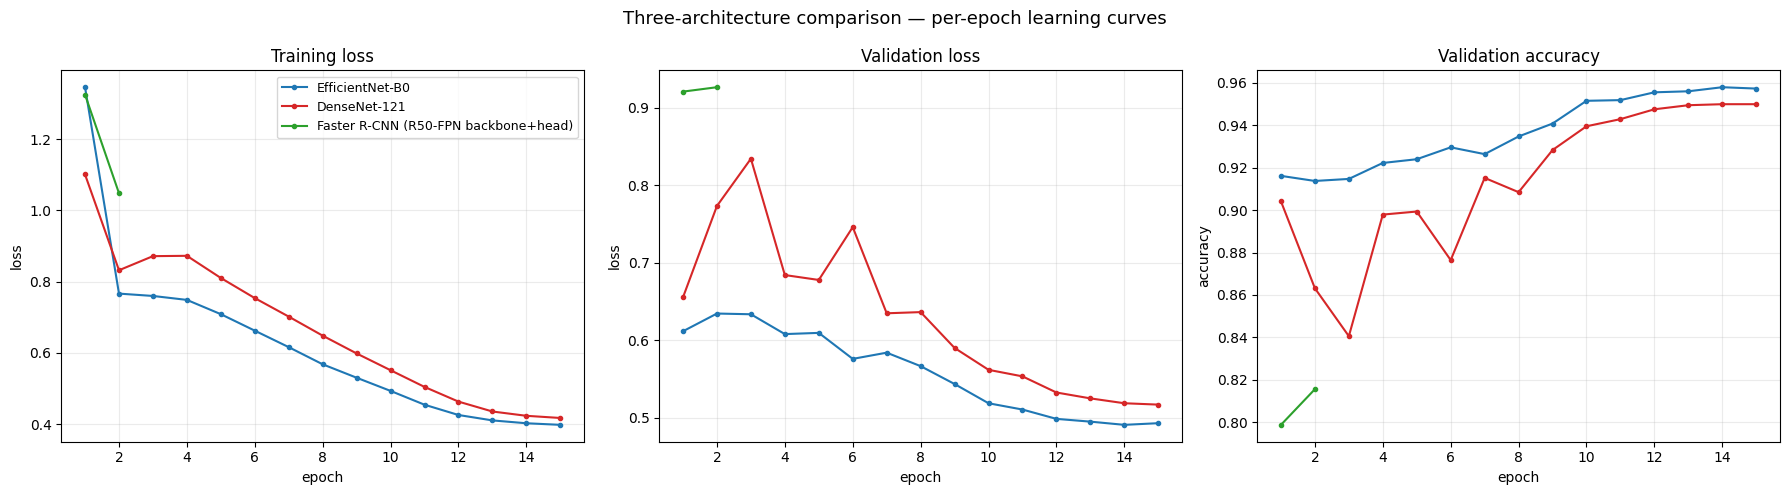

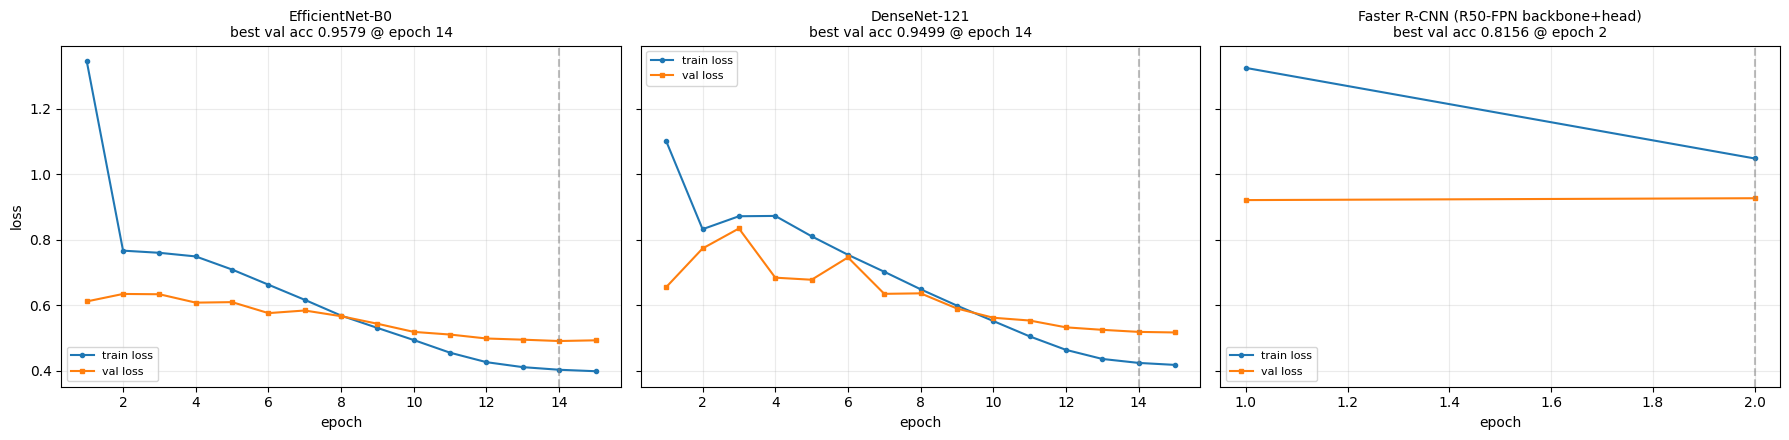

In [33]:
COLOURS = {"efficientnet_b0": "#1f77b4", "densenet121": "#d62728", "faster_rcnn_cls": "#2ca02c"}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
panels = [("train_loss", "Training loss", "loss"),
          ("val_loss", "Validation loss", "loss"),
          ("val_acc", "Validation accuracy", "accuracy")]

for ax, (column, title, ylabel) in zip(axes, panels):
    for key in MODELS_TO_RUN:
        frame = histories[key]
        ax.plot(frame["epoch"], frame[column], marker="o", markersize=3,
                color=COLOURS.get(key), label=MODEL_LABELS[key])
    ax.set_title(title, fontsize=12)
    ax.set_xlabel("epoch"); ax.set_ylabel(ylabel)
    ax.grid(alpha=0.25)
axes[0].legend(fontsize=9)

fig.suptitle("Three-architecture comparison — per-epoch learning curves", fontsize=13)
fig.tight_layout()
fig.savefig(CURVE_ROOT / "comparative_learning_curves.png", dpi=180, bbox_inches="tight")
plt.show()

# per-model train-vs-val overlay: the overfitting read
fig, axes = plt.subplots(1, len(MODELS_TO_RUN), figsize=(6 * len(MODELS_TO_RUN), 4.5), sharey=True)
axes = np.atleast_1d(axes)
for ax, key in zip(axes, MODELS_TO_RUN):
    frame = histories[key]
    ax.plot(frame["epoch"], frame["train_loss"], marker="o", markersize=3, label="train loss")
    ax.plot(frame["epoch"], frame["val_loss"], marker="s", markersize=3, label="val loss")
    best = frame.loc[frame["val_acc"].idxmax()]
    ax.axvline(best["epoch"], linestyle="--", alpha=0.5, color="grey")
    ax.set_title(f"{MODEL_LABELS[key]}\nbest val acc {best['val_acc']:.4f} @ epoch {int(best['epoch'])}",
                 fontsize=10)
    ax.set_xlabel("epoch"); ax.grid(alpha=0.25); ax.legend(fontsize=8)
axes[0].set_ylabel("loss")
fig.tight_layout()
fig.savefig(CURVE_ROOT / "train_vs_val_loss_per_model.png", dpi=180, bbox_inches="tight")
plt.show()

## 8. Final evaluation on the test split

Each model's **best-validation checkpoint** is reloaded and run once over the test split.
The test set is touched here and nowhere else — no threshold, no epoch and no
architecture choice was made using it.

Reported per model: test accuracy (the headline the comparison asks for), macro-F1 and
balanced accuracy (the honest numbers under a 6.6× class imbalance), plus a full
per-class report and confusion matrix written to `reports/`.

In [34]:
@torch.no_grad()
def evaluate(key):
    """Reload best checkpoint, run the test split, return (metrics dict, y_true, y_pred)."""
    checkpoint = torch.load(MODEL_ROOT / f"best_{key}.pt", map_location=DEVICE)
    model, _ = build_model(key)
    model.load_state_dict(checkpoint["state_dict"])
    model = model.to(DEVICE).eval()

    y_true, y_pred, confidences = [], [], []
    started = time.time()
    for images, targets in test_loader:
        with amp_context():
            logits = model(images.to(DEVICE, non_blocking=True))
        probabilities = torch.softmax(logits.float(), 1)
        top_p, top_i = probabilities.max(1)
        y_pred.extend(top_i.cpu().tolist())
        confidences.extend(top_p.cpu().tolist())
        y_true.extend(targets.tolist())
    elapsed = time.time() - started

    metrics = {
        "model": key,
        "architecture": MODEL_LABELS[key],
        "params_M": round(sum(p.numel() for p in model.parameters()) / 1e6, 2),
        "best_epoch": int(checkpoint.get("epoch", -1)),
        "best_val_acc": round(float(checkpoint.get("val_accuracy", float("nan"))), 4),
        "test_acc": round(accuracy_score(y_true, y_pred), 4),
        "test_macro_f1": round(f1_score(y_true, y_pred, average="macro", zero_division=0), 4),
        "test_balanced_acc": round(balanced_accuracy_score(y_true, y_pred), 4),
        "mean_confidence": round(float(np.mean(confidences)), 4),
        "inference_ms_per_image": round(1000 * elapsed / max(1, len(y_true)), 2),
        "weights_init": checkpoint.get("weights_note", ""),
    }

    labels_present = sorted(set(y_true) | set(y_pred))
    names = [id_to_class[i] for i in labels_present]

    report = pd.DataFrame(classification_report(
        y_true, y_pred, labels=labels_present, target_names=names,
        output_dict=True, zero_division=0)).T
    report.to_csv(REPORT_ROOT / f"per_class_report_{key}.csv")

    pd.DataFrame({"true_id": y_true, "pred_id": y_pred, "confidence": confidences,
                  "true_class": [id_to_class[i] for i in y_true],
                  "pred_class": [id_to_class[i] for i in y_pred]}
                 ).to_csv(REPORT_ROOT / f"test_predictions_{key}.csv", index=False)

    del model
    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()
    return metrics, y_true, y_pred


results, predictions = [], {}
for key in MODELS_TO_RUN:
    metrics, y_true, y_pred = evaluate(key)
    results.append(metrics)
    predictions[key] = (y_true, y_pred)
    print(f"{MODEL_LABELS[key]:<40} test acc {metrics['test_acc']:.4f} | "
          f"macro-F1 {metrics['test_macro_f1']:.4f} | balanced {metrics['test_balanced_acc']:.4f}")

comparison = pd.DataFrame(results).sort_values("test_acc", ascending=False).reset_index(drop=True)
comparison.to_csv(PROJECT_ROOT / "model_comparison.csv", index=False)
display(comparison)

EfficientNet-B0                          test acc 0.9562 | macro-F1 0.9200 | balanced 0.9204
DenseNet-121                             test acc 0.9537 | macro-F1 0.9155 | balanced 0.9151
Faster R-CNN (R50-FPN backbone+head)     test acc 0.8140 | macro-F1 0.7368 | balanced 0.7437


,model,architecture,params_M,best_epoch,best_val_acc,test_acc,test_macro_f1,test_balanced_acc,mean_confidence,inference_ms_per_image,weights_init
0,efficientnet_b0,EfficientNet-B0,4.04,14,0.9579,0.9562,0.9200,0.9204,0.9329,3.61,ImageNet
1,densenet121,DenseNet-121,6.98,14,0.9499,0.9537,0.9155,0.9151,0.9328,3.30,ImageNet
2,faster_rcnn_cls,Faster R-CNN (R50-FPN backbone+head),40.72,2,0.8156,0.8140,0.7368,0.7437,0.8102,3.69,COCO detection weights


### 8b. Test accuracy, side by side

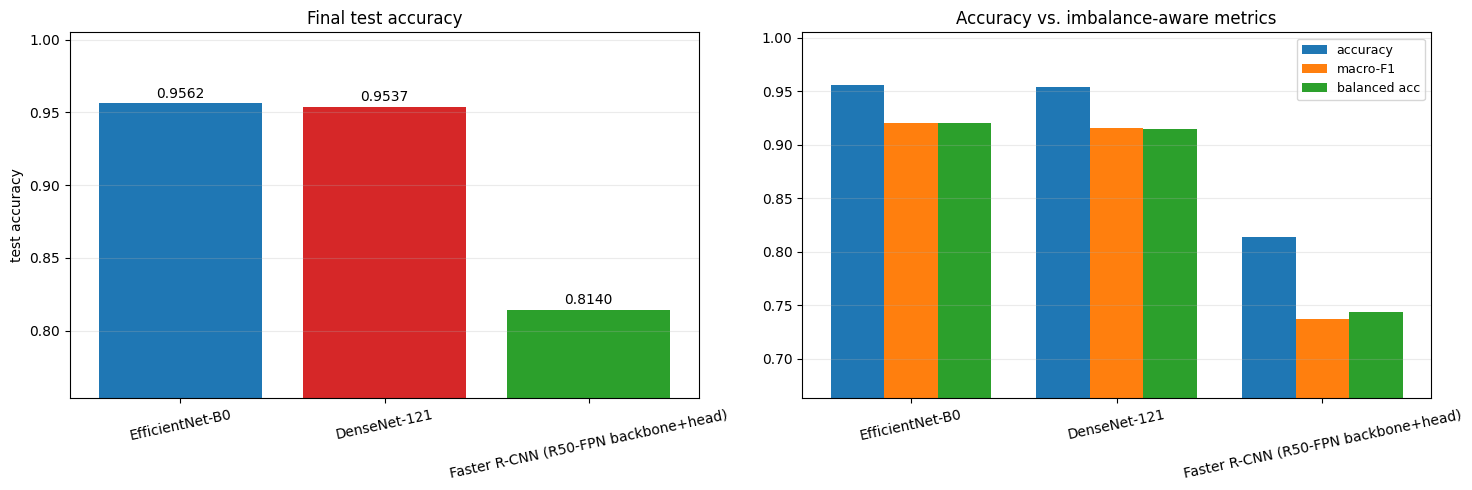

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

order = comparison["model"].tolist()
bar_colours = [COLOURS.get(k, "#777777") for k in order]

bars = axes[0].bar([MODEL_LABELS[k] for k in order], comparison["test_acc"], color=bar_colours)
for bar, value in zip(bars, comparison["test_acc"]):
    axes[0].text(bar.get_x() + bar.get_width() / 2, value + 0.004, f"{value:.4f}",
                 ha="center", fontsize=10)
axes[0].set_ylim(min(comparison["test_acc"]) - 0.06, 1.005)
axes[0].set_ylabel("test accuracy")
axes[0].set_title("Final test accuracy")
axes[0].tick_params(axis="x", rotation=12)
axes[0].grid(axis="y", alpha=0.25)

width, positions = 0.26, np.arange(len(order))
for offset, column, label in [(-width, "test_acc", "accuracy"),
                              (0.0, "test_macro_f1", "macro-F1"),
                              (width, "test_balanced_acc", "balanced acc")]:
    axes[1].bar(positions + offset, comparison[column], width, label=label)
axes[1].set_xticks(positions)
axes[1].set_xticklabels([MODEL_LABELS[k] for k in order], rotation=12)
axes[1].set_ylim(min(comparison["test_balanced_acc"]) - 0.08, 1.005)
axes[1].set_title("Accuracy vs. imbalance-aware metrics")
axes[1].legend(fontsize=9); axes[1].grid(axis="y", alpha=0.25)

fig.tight_layout()
fig.savefig(CURVE_ROOT / "test_accuracy_comparison.png", dpi=180, bbox_inches="tight")
plt.show()

### 8c. Confusion matrices

Same colour scale, same class order, so the three are directly comparable. Whatever the
accuracy ranking says, the interesting structure is *which* classes each architecture
loses — if all three fail on the same handful, that is a dataset problem, not a model
problem.

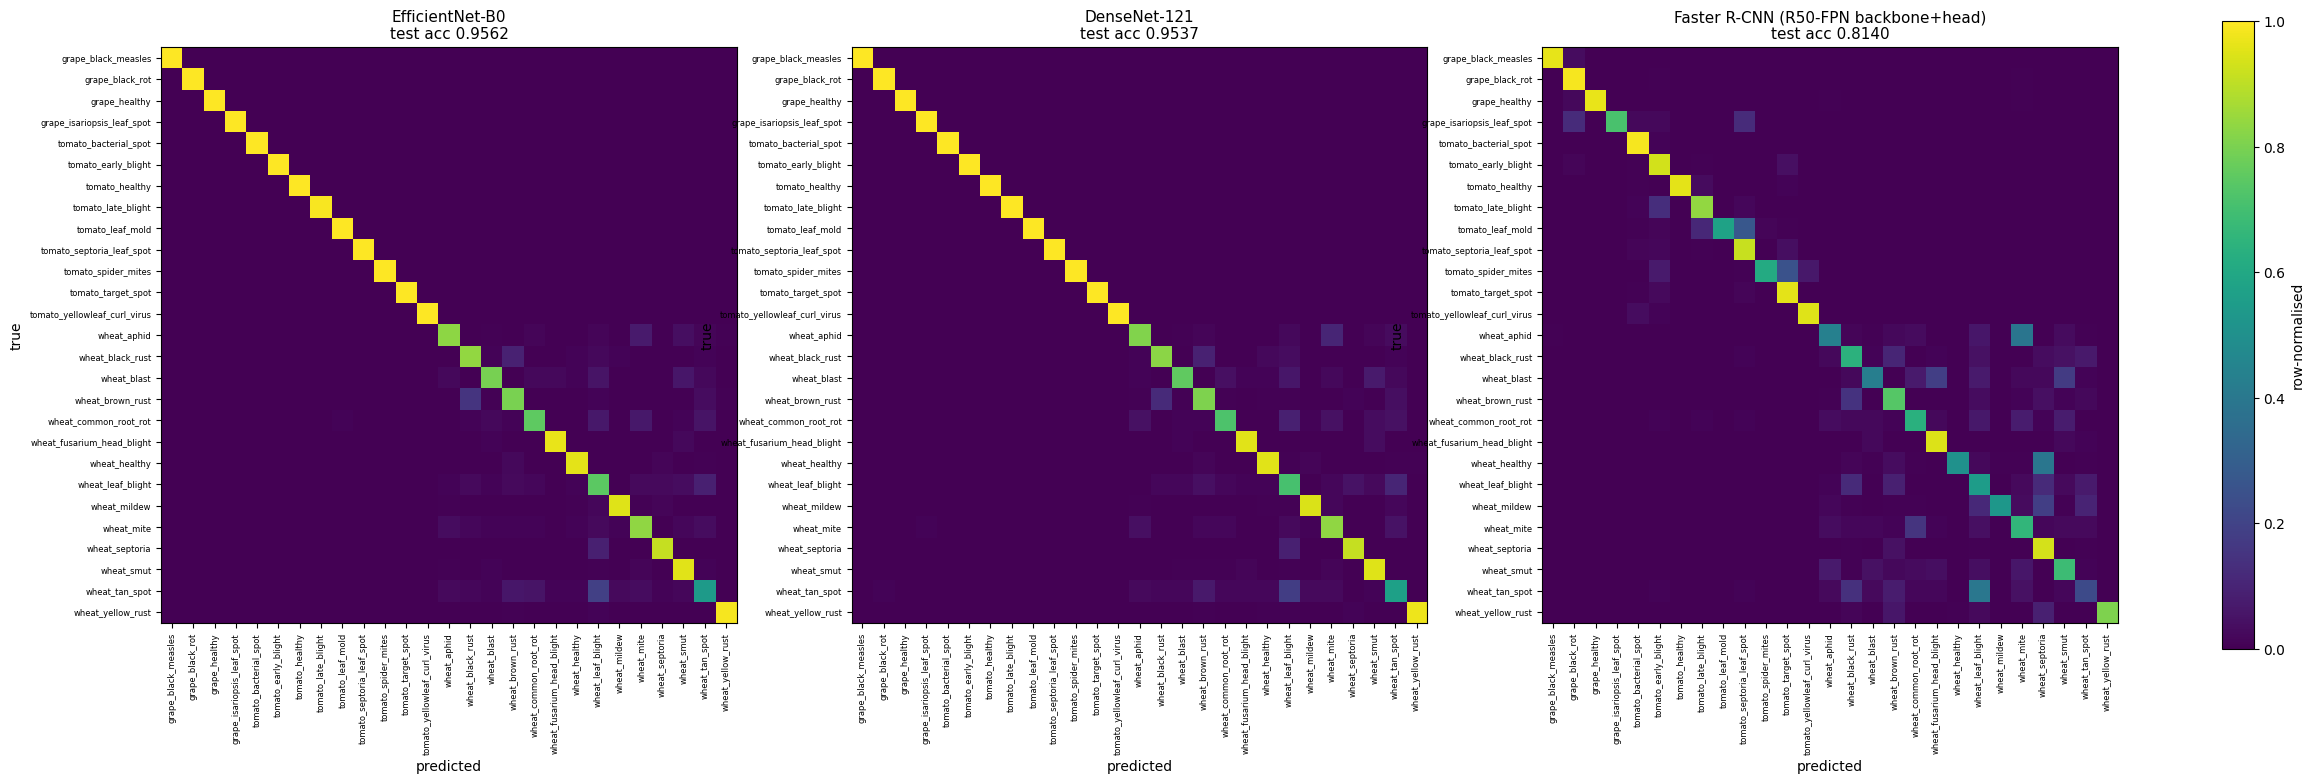

per-class recall, worst agreement first:


,EfficientNet-B0,DenseNet-121,Faster R-CNN (R50-FPN backbone+head),spread
wheat_healthy,0.960,0.953,0.507,0.453
tomato_leaf_mold,1.000,1.000,0.576,0.424
wheat_mildew,0.951,0.945,0.528,0.423
wheat_aphid,0.831,0.809,0.434,0.397
tomato_spider_mites,1.000,1.000,0.611,0.389
wheat_blast,0.796,0.755,0.429,0.367
wheat_tan_spot,0.543,0.569,0.224,0.345
grape_isariopsis_leaf_spot,1.000,1.000,0.711,0.289
wheat_smut,0.955,0.949,0.687,0.268
wheat_leaf_blight,0.748,0.709,0.551,0.197


In [26]:
labels_present = sorted(id_to_class)
names = [id_to_class[i] for i in labels_present]

fig, axes = plt.subplots(1, len(MODELS_TO_RUN),
                         figsize=(9 * len(MODELS_TO_RUN), 9))
axes = np.atleast_1d(axes)

for ax, key in zip(axes, MODELS_TO_RUN):
    y_true, y_pred = predictions[key]
    matrix = confusion_matrix(y_true, y_pred, labels=labels_present, normalize="true")
    image = ax.imshow(matrix, cmap="viridis", vmin=0, vmax=1)
    ax.set_title(f"{MODEL_LABELS[key]}\ntest acc "
                 f"{comparison.loc[comparison['model'] == key, 'test_acc'].iloc[0]:.4f}", fontsize=11)
    ax.set_xticks(range(len(names))); ax.set_xticklabels(names, rotation=90, fontsize=6)
    ax.set_yticks(range(len(names))); ax.set_yticklabels(names, fontsize=6)
    ax.set_xlabel("predicted"); ax.set_ylabel("true")

fig.colorbar(image, ax=axes, fraction=0.015, label="row-normalised")
fig.savefig(REPORT_ROOT / "confusion_matrices.png", dpi=160, bbox_inches="tight")
plt.show()

# where the three architectures disagree with each other, class by class
recall_table = pd.DataFrame({
    MODEL_LABELS[key]: pd.read_csv(REPORT_ROOT / f"per_class_report_{key}.csv",
                                   index_col=0)["recall"].reindex(names).round(3)
    for key in MODELS_TO_RUN
})
recall_table["spread"] = (recall_table.max(axis=1) - recall_table.min(axis=1)).round(3)
recall_table = recall_table.sort_values("spread", ascending=False)
recall_table.to_csv(REPORT_ROOT / "per_class_recall_comparison.csv")
print("per-class recall, worst agreement first:")
display(recall_table.head(15))

## 9. Package the run

Everything the write-up needs: the manifest, the class index, three checkpoints, three
per-epoch histories, the curve figures and the test reports. The best-performing model is
also copied to `best_cnn.pt` in the checkpoint format the deployment app already expects,
so swapping the winner into the Flask app is a file copy rather than a code change.

In [27]:
winner = comparison.iloc[0]["model"]
shutil.copy(MODEL_ROOT / f"best_{winner}.pt", PROJECT_ROOT / "best_cnn.pt")
print("winner:", MODEL_LABELS[winner], "-> best_cnn.pt "
      f"(test acc {comparison.iloc[0]['test_acc']:.4f})")

summary = {
    "images": int(len(manifest)),
    "classes": int(NUM_CLASSES),
    "splits": manifest["split"].value_counts().to_dict(),
    "image_size": IMAGE_SIZE,
    "batch_size": BATCH_SIZE,
    "epochs": EPOCHS,
    "learning_rate": LEARNING_RATE,
    "learning_rate_overrides": LEARNING_RATE_BY_MODEL,
    "balanced_sampler": BALANCE_CLASSES,
    "results": comparison.to_dict(orient="records"),
    "winner": winner,
}
(PROJECT_ROOT / "experiment_summary.json").write_text(json.dumps(summary, indent=2), encoding="utf-8")

zip_path = shutil.make_archive("/kaggle/working/PlantCare_CNN_3model", "zip", PROJECT_ROOT)
print("Download:", zip_path)
for path in sorted(PROJECT_ROOT.rglob("*")):
    if path.is_file():
        print(" ", path.relative_to(PROJECT_ROOT), f"({path.stat().st_size/1024:.0f} KB)")

winner: EfficientNet-B0 -> best_cnn.pt (test acc 0.9562)
Download: /kaggle/working/PlantCare_CNN_3model.zip
  best_cnn.pt (16087 KB)
  class_index.json (1 KB)
  curves/comparative_learning_curves.png (199 KB)
  curves/test_accuracy_comparison.png (102 KB)
  curves/train_vs_val_loss_per_model.png (132 KB)
  experiment_summary.json (1 KB)
  histories/history_densenet121.csv (2 KB)
  histories/history_efficientnet_b0.csv (2 KB)
  histories/history_faster_rcnn_cls.csv (0 KB)
  manifest.csv (8039 KB)
  model_comparison.csv (0 KB)
  models/best_densenet121.pt (27870 KB)
  models/best_efficientnet_b0.pt (16087 KB)
  models/best_faster_rcnn_cls.pt (159593 KB)
  reports/confusion_matrices.png (194 KB)
  reports/per_class_recall_comparison.csv (1 KB)
  reports/per_class_report_densenet121.csv (2 KB)
  reports/per_class_report_efficientnet_b0.csv (2 KB)
  reports/per_class_report_faster_rcnn_cls.csv (2 KB)
  reports/test_predictions_densenet121.csv (381 KB)
  reports/test_predictions_efficientnet

---

### Reading the result honestly

1. **Test accuracy alone will flatter all three.** Grape and tomato classes sit at
   0.99–1.00 F1 in this dataset and they dominate the count; nearly all the error is in
   wheat. Quote macro-F1 and balanced accuracy next to accuracy, and quote the per-class
   recall table — a 0.3% accuracy gap between two architectures is noise, a 0.15 recall
   gap on `wheat_tan_spot` is a finding.
2. **One seed is one sample.** If two models land within ~0.5% of each other you cannot
   rank them from a single run. Re-run with 2–3 seeds and report mean ± spread before
   claiming one architecture beats another.
3. **The Faster R-CNN entry is a backbone/head transplant, not a detector.** It produces
   no boxes and is never scored on localisation — describe it that way in the paper. Its
   fair comparison point is "ResNet-50+FPN features with a COCO-pretrained MLP head",
   which is the honest claim, and its COCO initialisation is a different pretraining
   source from the other two (ImageNet). Say so.
4. **Learning rate is not identical across the three** unless you set
   `LEARNING_RATE_BY_MODEL = {}`. As shipped, the Faster R-CNN variant runs at 1e-4 to
   keep a large pretrained ResNet-50 stable. Either report the override or run everything
   untuned — both are defensible, silence is not.
5. **Localisation and severity are out of scope here by design.** They lived in the
   removed green-channel section; if that output is still wanted downstream it belongs in
   its own notebook, so the classification benchmark stays clean.